<a href="https://colab.research.google.com/github/ananthakrishnanm010/Case_Study_on_Preprocessing/blob/main/CNN_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import VGG16
import pickle     # for loading dataset
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Read Data

In [ ]:
dataset_path = "/content/drive/MyDrive/CIFAR-100"

# Load dataset
def load_file(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f, encoding='bytes')
    return data

train = load_file(dataset_path + "/train")
test = load_file(dataset_path + "/test")

In [ ]:
# Splitting to train and test data
X_train = train[b'data']
y_train = np.array(train[b'fine_labels'])

X_test = test[b'data']
y_test = np.array(test[b'fine_labels'])

#Data Preprocessing

In [ ]:
print("Number of classes of dataset:", len(np.unique(y_train)))

Number of classes of dataset: 100


In [ ]:
print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (50000, 3072)
Training Labels: (50000,)
Testing Images: (10000, 3072)
Testing Labels: (10000,)


In [ ]:
print(X_train.dtype)
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [ ]:
X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

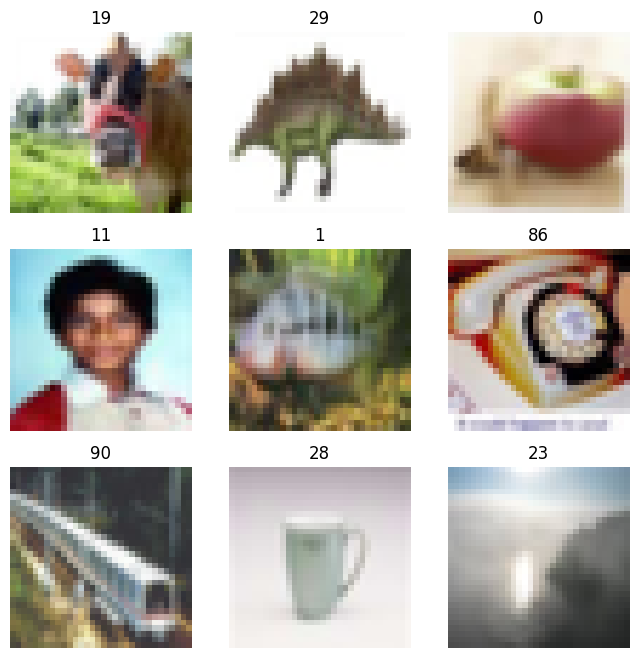

In [ ]:
plt.figure(figsize = (8,8))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i])
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [ ]:
# First, select 10000 images from the original training set
X_subset, _, y_subset, _ = train_test_split(
    X_train,
    y_train,
    train_size = 40000,
    stratify = y_train,
    random_state = 42
)

# Now split the 10000 images into 80% train and 20% test
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_subset,
    y_subset,
    test_size = 0.2,
    stratify = y_subset,
    random_state = 42
)

print(X_train_small.shape)
print(y_train_small.shape)
print(X_test_small.shape)
print(y_test_small.shape)

(32000, 32, 32, 3)
(32000,)
(8000, 32, 32, 3)
(8000,)


In [ ]:
# Normalization

X_train_small = X_train_small.astype("float32") / 255.0
X_test_small = X_test_small.astype("float32") / 255.0

In [ ]:
# Onehot encode the labels

y_train_small = to_categorical(y_train_small, 100)
y_test_small = to_categorical(y_test_small, 100)

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range = 10,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    zoom_range = 0.1
)

#Model Building

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    # Block 1
    tf.keras.layers.Conv2D(64, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.2),

    # Block 2
    tf.keras.layers.Conv2D(128, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.3),

    # Block 3
    tf.keras.layers.Conv2D(256, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(256, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.4),

    # Block 4
    tf.keras.layers.Conv2D(512, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.4),

    # Classifier
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(512, activation = 'relu', kernel_initializer = 'he_normal',
                           kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(100, activation = 'softmax')
])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,647,204 (10.10 MB)

 Trainable params: 2,643,364 (10.08 MB)

 Non-trainable params: 3,840 (15.00 KB)

## Compile Model

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

##Training

In [ ]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

checkpoint = ModelCheckpoint(
    'best_custom_cnn.keras',
    monitor = 'val_accuracy',
    save_best_only = True,
    mode = 'max',
    verbose = 1
)

In [ ]:
# Model Training

history = model.fit(
    train_datagen.flow(X_train_small, y_train_small, batch_size = 32),
    epochs = 30,
    validation_data = (X_test_small, y_test_small),
    callbacks = [early_stop, checkpoint]
)

Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0437 - loss: 5.3022
Epoch 1: val_accuracy improved from None to 0.11838, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.0614 - loss: 4.9335 - val_accuracy: 0.1184 - val_loss: 4.2924
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1082 - loss: 4.3663
Epoch 2: val_accuracy improved from 0.11838 to 0.16725, saving model to best_custom_cnn.keras

Epoch 2: finished saving model to best_custom_cnn.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.1268 - loss: 4.2199 - val_accuracy: 0.1673 - val_loss: 3.8421
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1756 - loss: 3.8202
Epoch 3: val_accuracy improved from 0.16725 to 0.24000, saving model to best_custom_cnn.keras

Epoch 3: finished saving model to best_custom_cnn.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/s

#Evaluation

In [ ]:
loss, accuracy = model.evaluate(X_test_small, y_test_small)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5056 - loss: 2.5972
Test Loss: 2.597153663635254
Test Accuracy: 0.5056250095367432


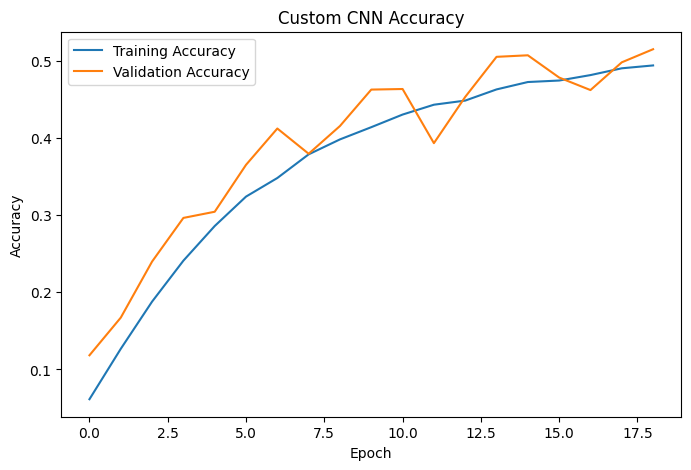

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')

plt.title('Custom CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])


Training Accuracy: 0.4944687485694885
Validation Accuracy: 0.515500009059906
Training Loss: 2.7041008472442627
Validation Loss: 2.607287883758545
